# 04-LangGraph Foundations (State & Nodes)

In Lesson 03, we perfected our agent's cognitive structure using Pydantic Coercion. We can mathematically guarantee that any data generated by an LLM strictly conforms to our required topologies.

But where does this structured data go? In a single-turn application, we simply return it to the user. But in an autonomous, multi-step Agentic Workflow, this data must be preserved, mutated, and passed forward into the next computational step.

We must graduate from simple sequential chains into the mathematics of **Graph Theory and State Machines**. The enterprise standard for this orchestration is **LangGraph**.

Let's set up our environment to engineer the physics of the `StateGraph`.

In [2]:
# Required installations: pip install langchain langchain-core langchain-ollama langgraph matplotlib seaborn
from typing import TypedDict, Annotated
import operator
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & LangGraph Environment Ready.")

✅ Systems Architecture & LangGraph Environment Ready.


# 1. The Physics of the State Machine ($S_t$)

At the core of LangGraph is a single, unified mathematical payload called the **State** ($S$).

In standard Python programming, you pass variables individually between functions: `y = func(x, z)`.
In a LangGraph State Machine, **all functions accept the exact same object ($S$) and return a delta ($\Delta S$) to update it.**

Let $S_t$ be the state of our agent at time $t$. Let $N$ be a Node (a Python function).
The computation resolves as:


$$S_{t+1} = S_t \oplus N(S_t)$$

The $\oplus$ operator is critical. When a node returns data, LangGraph does not blindly overwrite the old state. It uses **Reducers** to merge the data based on your mathematical definitions.

### The `TypedDict` and the Reducer Matrix

We define the structure of $S$ using a Python `TypedDict`. For every variable in the State, we define its type and its **Reducer**.

* **Overwrite (Default)**: If Node A returns `{"summary": "..."}`, the state's summary is completely replaced.
* **Append (`Annotated[list, operator.add]`)**: If Node A returns `{"drafts": ["Draft 1"]}`, LangGraph appends the string to the existing list, physically preserving the computational history.

# 2. Architecting the Nodes and Edges

A LangGraph is built using three primitives:

1. **Nodes ($V$)**: Pure Python functions that contain the computational logic (e.g., prompting an LLM, triggering a tool). A node accepts $S_t$ and returns $\Delta S$.
2. **Edges ($E$)**: The directional routing logic. Standard edges connect Node A strictly to Node B.
3. **The Graph ($G$)**: The compilation of Nodes and Edges into a single, executable LangChain `Runnable`.


# 3. Building the Physical StateGraph

Let's build a functional, multi-node LangGraph using local Llama 3.2. We will engineer a dual-agent pipeline:

1. **The Generator Node**: Takes a topic and drafts an initial response.
2. **The Critic Node**: Reads the draft, critiques it, and outputs a final polished version.

In [3]:
# --- 🕸️ The LangGraph State Machine Engine ---

# 1. Define the Mathematical State (The Global Payload)
class AgentState(TypedDict):
    topic: str
    # Use operator.add to APPEND drafts to a list rather than overwriting
    drafts: Annotated[list[str], operator.add]
    final_review: str

# Initialize the local policy network
llm = ChatOllama(model="llama3.2", temperature=0.7)

# 2. Define the Computational Nodes
def generator_node(state: AgentState) -> dict:
    """Reads the topic, queries Llama 3.2, and APPENDS the draft to the state."""
    print("   ✍️ [NODE: Generator] Drafting initial content...")
    topic = state["topic"]
    
    prompt = [
        SystemMessage(content="You are an expert copywriter. Write a 2-sentence pitch about the topic."),
        HumanMessage(content=f"Topic: {topic}")
    ]
    
    # Physical LLM Forward Pass
    response = llm.invoke(prompt)
    
    # Return the Delta (LangGraph will apply `operator.add` to the 'drafts' list)
    return {"drafts": [response.content]}

def critic_node(state: AgentState) -> dict:
    """Reads the appended draft, critiques it, and OVERWRITES the final_review."""
    print("   🧐 [NODE: Critic] Reviewing and polishing the draft...")
    
    # Extract the most recent draft from the state history
    current_draft = state["drafts"][-1] 
    
    prompt = [
        SystemMessage(content="You are a strict editor. Take the draft, fix any flaws, and output the final polished 1-sentence version."),
        HumanMessage(content=f"Draft to edit: {current_draft}")
    ]
    
    # Physical LLM Forward Pass
    response = llm.invoke(prompt)
    
    # Return the Delta (LangGraph will OVERWRITE 'final_review')
    return {"final_review": response.content}

# 3. Architect the Graph Topology
print("--- 🏗️ Compiling the StateGraph ---")
workflow = StateGraph(AgentState)

# Add the physical nodes to the graph
workflow.add_node("Generator", generator_node)
workflow.add_node("Critic", critic_node)

# Define the directional flow (Edges)
workflow.add_edge(START, "Generator")
workflow.add_edge("Generator", "Critic")
workflow.add_edge("Critic", END)

# Compile the graph into an executable application
app = workflow.compile()

# 4. Execute the Physical Graph
print("\n--- 🚀 Initializing StateGraph Execution ---")

# The Initial State (S_0)
S_0 = {"topic": "Autonomous Swarm Drones", "drafts": [], "final_review": ""}
print(f"S_0 (Start State): Topic='{S_0['topic']}'\n")

# Stream the graph execution to watch the physical state mutate in real-time
for output in app.stream(S_0):
    for node_name, state_delta in output.items():
        print(f"\n[Delta from '{node_name}'] -> {state_delta}")

# Retrieve the final state from the application
final_state = app.invoke(S_0)

print("\n--- 🏁 Final Preserved State Object ---")
print(f"Topic: {final_state['topic']}")
print(f"Draft History (Length {len(final_state['drafts'])}): '{final_state['drafts'][0]}'")
print(f"Final Polish: '{final_state['final_review']}'")

print("\n--- 💡 Engineering Insight ---")
print("Notice how the Nodes communicate. The Critic Node has no direct parameter linkage to the Generator Node. It doesn't accept arguments directly from the Generator. Both nodes are completely decoupled functions that only interact by reading and mutating the shared `AgentState` object. If we wanted to add a 'FactChecker' node in between them, we would simply drop it into the graph without rewriting the internal logic of the existing nodes.")

--- 🏗️ Compiling the StateGraph ---

--- 🚀 Initializing StateGraph Execution ---
S_0 (Start State): Topic='Autonomous Swarm Drones'

   ✍️ [NODE: Generator] Drafting initial content...

[Delta from 'Generator'] -> {'drafts': ['Here\'s a 2-sentence pitch:\n\n"Imagine a world where drones work together in perfect harmony to accomplish complex tasks, such as environmental monitoring, search and rescue operations, and infrastructure inspection - our autonomous swarm drone technology makes this vision a reality. By leveraging cutting-edge AI and machine learning algorithms, we\'re developing a new generation of drones that can adapt, communicate, and cooperate with unprecedented levels of autonomy, unlocking new possibilities for industries and communities worldwide."']}
   🧐 [NODE: Critic] Reviewing and polishing the draft...

[Delta from 'Critic'] -> {'final_review': 'Here is the revised 1-sentence pitch:\n\nOur autonomous swarm drone technology harnesses cutting-edge AI and machine learn

# 4. Visualizing Graph Topology

To mathematically prove how state flows through an orchestrated network, let's visualize the Directed Acyclic Graph (DAG) we just built, tracking the precise moment the Reducers act on the State schema.

/tmp/ipykernel_13612/3102310808.py:40: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  state_box = patches.Rectangle((4.5, 0), 5, 1.5, fill=True, color='#f1c40f', alpha=0.2, linewidth=2, edgecolor='black')


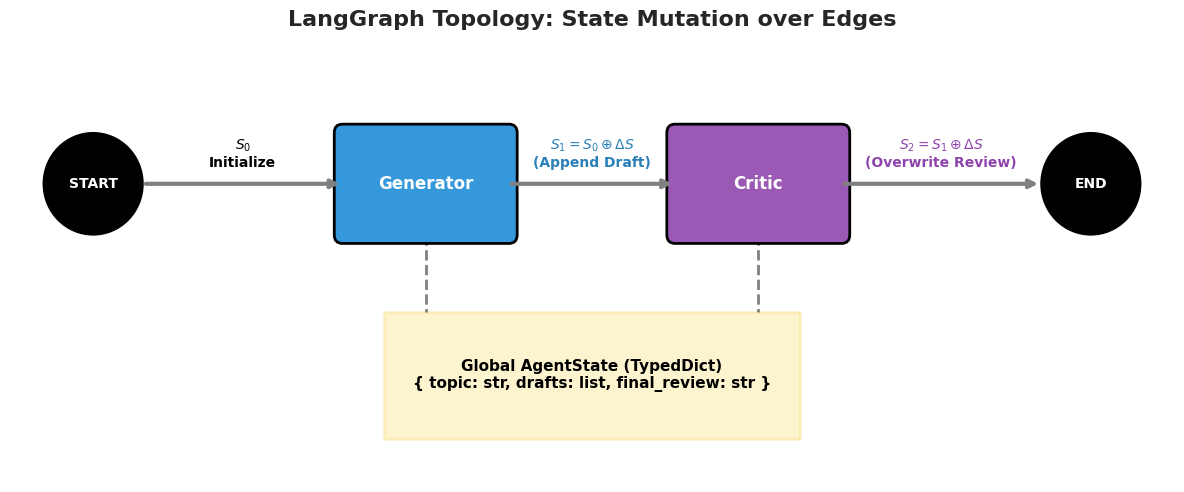

In [4]:
# Visualizing the StateGraph Topology
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("LangGraph Topology: State Mutation over Edges", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Draw Nodes (Vertices)
nodes = {
    "__START__": (1, 3, "black", "white"),
    "Generator": (5, 3, "#3498db", "white"),
    "Critic": (9, 3, "#9b59b6", "white"),
    "__END__": (13, 3, "black", "white")
}

for name, (x, y, color, text_color) in nodes.items():
    if name in ["__START__", "__END__"]:
        circle = patches.Circle((x, y), 0.6, color=color, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, name.strip("_"), color=text_color, fontweight='bold', ha='center', va='center', fontsize=10, zorder=4)
    else:
        rect = patches.FancyBboxPatch((x-1, y-0.6), 2, 1.2, boxstyle="round,pad=0.1", 
                                     linewidth=2, edgecolor='black', facecolor=color, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, name, color=text_color, fontweight='bold', ha='center', va='center', fontsize=12, zorder=4)

# 2. Draw Edges and State Updates
# START -> Generator
ax.annotate("", xy=(4, 3), xytext=(1.6, 3), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))
ax.text(2.8, 3.2, "$S_0$\nInitialize", ha='center', fontsize=10, fontweight='bold', color="black")

# Generator -> Critic
ax.annotate("", xy=(8, 3), xytext=(6, 3), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))
ax.text(7, 3.2, "$S_1 = S_0 \\oplus \\Delta S$\n(Append Draft)", ha='center', fontsize=10, fontweight='bold', color="#2980b9")

# Critic -> END
ax.annotate("", xy=(12.4, 3), xytext=(10, 3), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))
ax.text(11.2, 3.2, "$S_2 = S_1 \\oplus \\Delta S$\n(Overwrite Review)", ha='center', fontsize=10, fontweight='bold', color="#8e44ad")

# 3. Draw the Global State Object (The Clipboard)
state_box = patches.Rectangle((4.5, 0), 5, 1.5, fill=True, color='#f1c40f', alpha=0.2, linewidth=2, edgecolor='black')
ax.add_patch(state_box)
ax.text(7, 0.75, "Global AgentState (TypedDict)\n{ topic: str, drafts: list, final_review: str }", 
        ha='center', va='center', color='black', fontweight='bold', fontsize=11)

# Draw lines connecting nodes to the Global State
ax.plot([5, 5], [2.4, 1.5], color='gray', linestyle='--', linewidth=2)
ax.plot([9, 9], [2.4, 1.5], color='gray', linestyle='--', linewidth=2)

plt.xlim(0, 14)
plt.ylim(-0.5, 4.5)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of a LangGraph State Machine like a **Hospital Patient Chart**:

* **The State ($S$)**: The physical clipboard attached to the patient's bed (The `AgentState`). It has strict mathematical sections defined: *Patient Name* (Overwrite), *Symptoms* (Append list), *Final Diagnosis* (Overwrite).
* **The Nodes ($V$)**: The hospital staff.
* Node 1 is the **Triage Nurse**. They read the Name, check the temperature, and *append* a symptom to the chart. They never diagnose the patient. They simply hand the clipboard down the hallway.
* Node 2 is the **Doctor**. They don't need to talk to the nurse directly. They just read the global chart (State), realize there are 3 symptoms appended, formulate a diagnosis using their specialized training, and *overwrite* the blank Diagnosis line.


* **The Edges ($E$)**: The physical path the clipboard takes down the hallway.

Because the staff (Nodes) communicate entirely through the standardized chart (State), you can infinitely scale the hospital. You can seamlessly insert an X-Ray Tech Node or a Pharmacy Node into the Graph without breaking the existing communication pathways.